In [1]:
import numpy as np
import sep

In [2]:
# additional setup for reading the test image and displaying plots
from astropy.io import fits
import matplotlib.pyplot as plt
from matplotlib import rcParams

%matplotlib inline

rcParams['figure.figsize'] = [10., 8.]

In [3]:
# read image into standard 2-d numpy array
hdu = fits.open("data/jw02731-o001_t017_nircam_clear-f090w_i2d.fits")
data = hdu["SCI"].data

data = data.astype(data.dtype.newbyteorder('='))

In [4]:
def rescale_image(data,vmin=0.5,vmax=100):
    # copy the data to avoid accidentaly overwriting it
    data_tmp = data.copy()

    # compute the mean value over all data, excluding NaN (Not a Number)
    m = np.nanmean(data_tmp)

    # any data points below vpmin is assigned the value vpmin
    # any data points above vpmax is assigned the value vpmax
    vpmin = vmin * m
    vpmax = vmax * m
    data_tmp[data_tmp < vpmin] = vpmin
    data_tmp[data_tmp > vpmax] = vpmax
    
    # replace all NaN by vpmin
    data_tmp = np.nan_to_num(data_tmp,nan=vpmin)

    # apply log-scale
    data_tmp = np.log10(data_tmp)
    return data_tmp

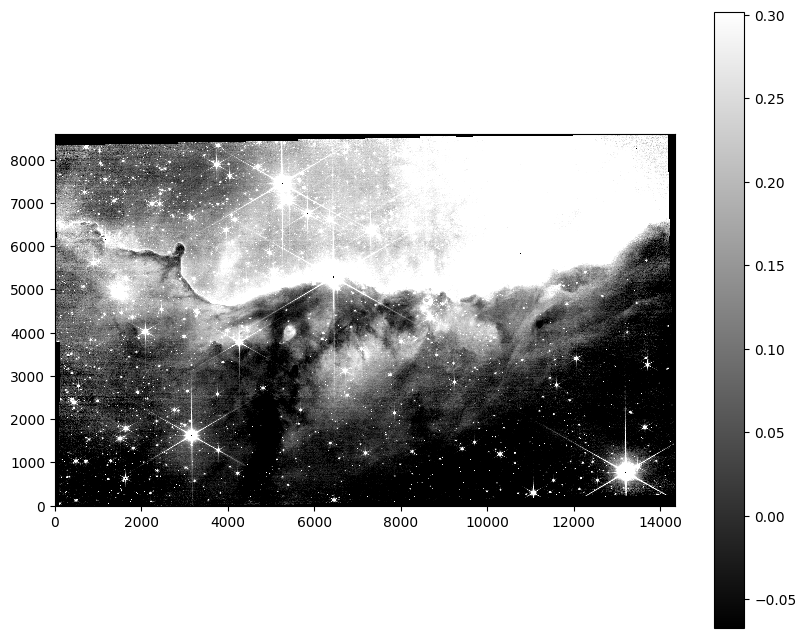

In [5]:
# show the image
rescale = rescale_image(data)
m, s = np.mean(rescale), np.std(rescale)
plt.imshow(rescale, interpolation='nearest', cmap='gray', vmin=m-s, vmax=m+s, origin='lower')
plt.colorbar();
plt.savefig("clear-f090w_original.png")

In [6]:
# measure a spatially varying background on the image
bkg = sep.Background(rescale)

In [7]:
# get a "global" mean and noise of the image background:
print(bkg.globalback)
print(bkg.globalrms)

0.06995680183172226
0.018640009686350822


In [8]:
# evaluate background as 2-d array, same size as original image
bkg_image = bkg.back()
# bkg_image = np.array(bkg) # equivalent to above

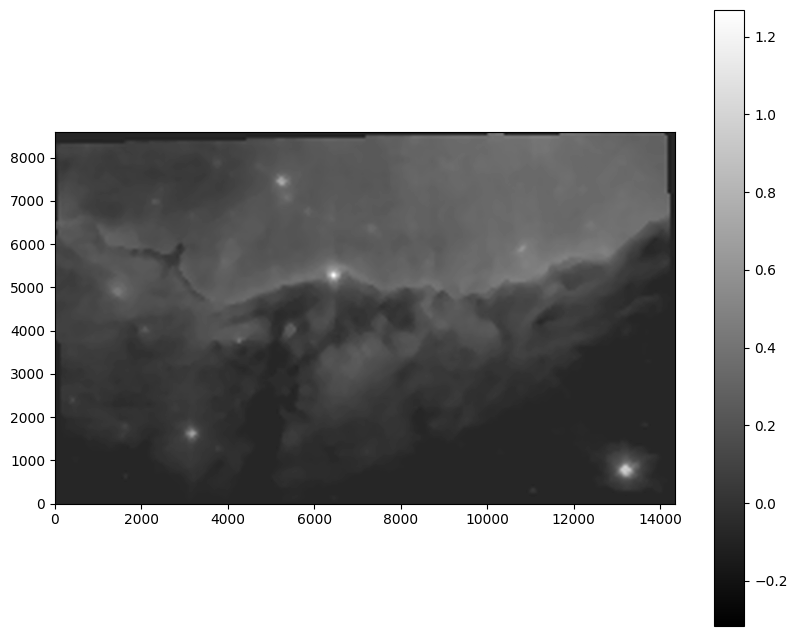

In [9]:
# show the background
plt.imshow(bkg_image, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();
plt.savefig("clear-f090w_bg.png")

In [10]:
# evaluate the background noise as 2-d array, same size as original image
bkg_rms = bkg.rms()

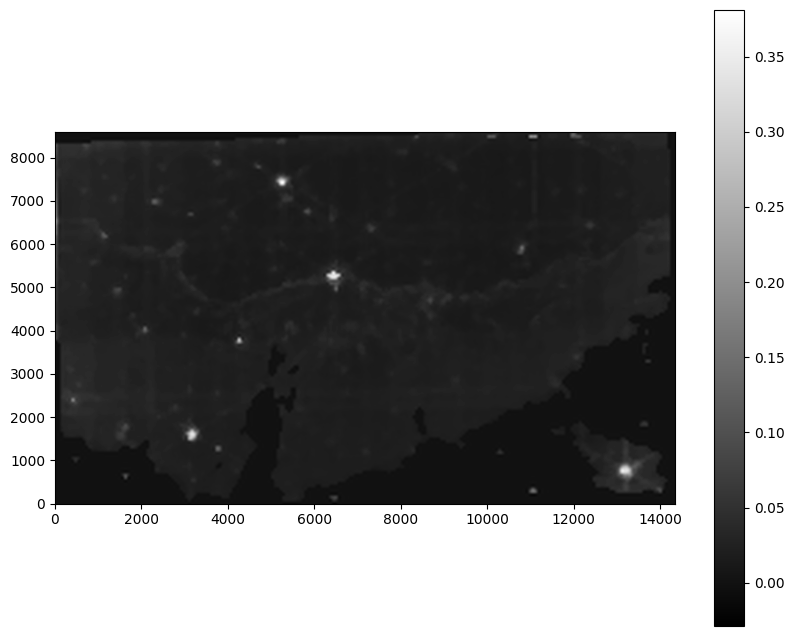

In [11]:
# show the background noise
plt.imshow(bkg_rms, interpolation='nearest', cmap='gray', origin='lower')
plt.colorbar();
plt.savefig("clear-f090w_bg_noise.png")

In [12]:
# subtract the background
data_sub = rescale - bkg

In [13]:
objects = sep.extract(data_sub, 60, err=bkg.globalrms)

In [14]:
# how many objects were detected
len(objects)

2469

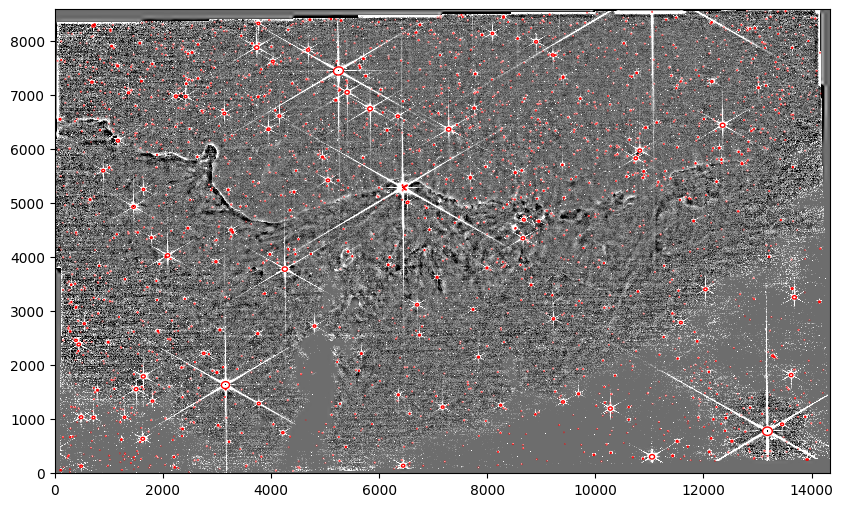

In [15]:
from matplotlib.patches import Ellipse

# plot background-subtracted image
fig, ax = plt.subplots()
m, s = np.mean(data_sub), np.std(data_sub)
im = ax.imshow(data_sub, interpolation='nearest', cmap='gray',
               vmin=m-s, vmax=m+s, origin='lower')

# plot an ellipse for each object
for i in range(len(objects)):
    e = Ellipse(xy=(objects['x'][i], objects['y'][i]),
                width=6*objects['a'][i],
                height=6*objects['b'][i],
                angle=objects['theta'][i] * 180. / np.pi)
    e.set_facecolor('none')
    e.set_edgecolor('red')
    ax.add_artist(e)

plt.savefig("clear-f090w_obj_det.png")

In [16]:
# available fields
objects.dtype.names

('thresh',
 'npix',
 'tnpix',
 'xmin',
 'xmax',
 'ymin',
 'ymax',
 'x',
 'y',
 'x2',
 'y2',
 'xy',
 'errx2',
 'erry2',
 'errxy',
 'a',
 'b',
 'theta',
 'cxx',
 'cyy',
 'cxy',
 'cflux',
 'flux',
 'cpeak',
 'peak',
 'xcpeak',
 'ycpeak',
 'xpeak',
 'ypeak',
 'flag')

In [17]:
flux, fluxerr, flag = sep.sum_circle(data_sub, objects['x'], objects['y'],
                                     3.0, err=bkg.globalrms, gain=1.0)

In [18]:
# show the first 10 objects results:
for i in range(10):
    print("object {:d}: flux = {:f} +/- {:f}".format(i, flux[i], fluxerr[i]))

object 0: flux = 26.224221 +/- 5.121916
object 1: flux = 33.912891 +/- 5.824322
object 2: flux = 31.518079 +/- 5.614974
object 3: flux = 37.760996 +/- 6.145790
object 4: flux = 34.782755 +/- 5.898521
object 5: flux = 41.621369 +/- 6.452227
object 6: flux = 54.801588 +/- 7.403471
object 7: flux = 27.511558 +/- 5.246084
object 8: flux = 39.435882 +/- 6.280580
object 9: flux = 27.326425 +/- 5.228405


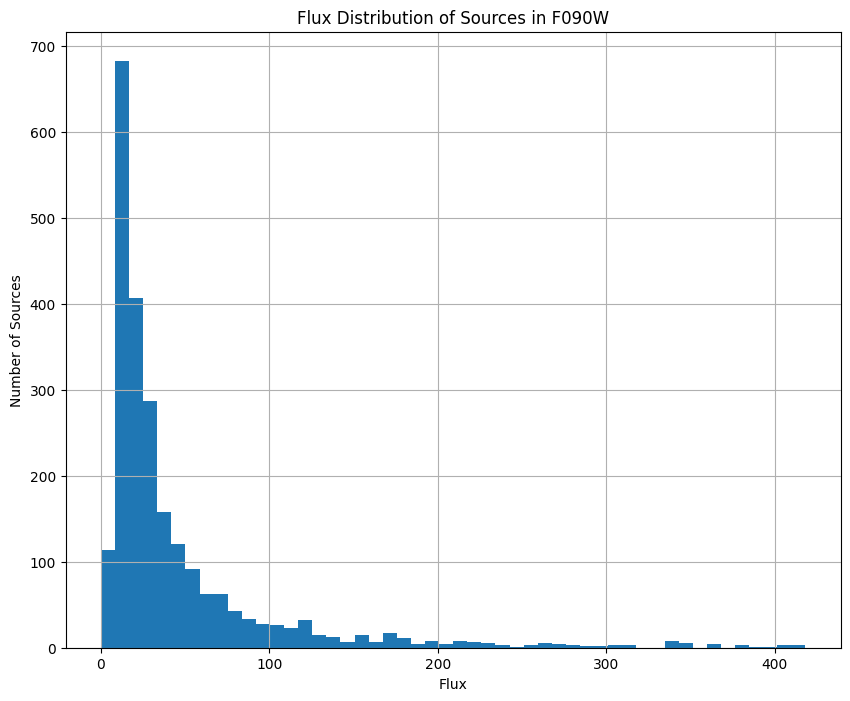

Detected 2469 sources


In [19]:
fluxes = np.array([obj['flux'] for obj in objects])

plt.hist(fluxes, bins=50, range=(0, np.percentile(fluxes, 95)))
plt.xlabel("Flux")
plt.ylabel("Number of Sources")
plt.title("Flux Distribution of Sources in F090W")
plt.grid(True)
plt.show()

print(f"Detected {len(objects)} sources")

In [20]:
mean_flux = np.mean(fluxes)
median_flux = np.median(fluxes)
std_flux = np.std(fluxes)

print(f"Mean flux: {mean_flux:.2f}")
print(f"Median flux: {median_flux:.2f}")
print(f"Standard deviation of flux: {std_flux:.2f}")

i_max = np.argmax(fluxes)
brightest = objects[i_max]

outlier_flux = brightest['flux']
x_outlier = brightest['x']
y_outlier = brightest['y']
n_sigma = (outlier_flux - mean_flux) / std_flux

print(f"\nThe outlier is {outlier_flux:.2f} located at (x={x_outlier:.1f}, y={y_outlier:.1f})")
print(f"This is {n_sigma:.2f}σ above the mean.")


Mean flux: 106.69
Median flux: 26.04
Standard deviation of flux: 379.96

The outlier is 7588.38 located at (x=13183.6, y=777.2)
This is 19.69σ above the mean.


In [21]:
# ---------------------------------
# 0. Copy all this script into one cell, between steps 7 and 8 of your final project
#    You will need to install the "reproject" package with pip
#    This script will "reproject" all images onto the same shape using one image as a reference
# ---------------------------------

from astropy.io import fits
from astropy.wcs import WCS
from reproject import reproject_interp

# ---------------------------------
# 1. Load your reference image
#    This will define the WCS and shape for all others
# ---------------------------------
file_reference = "data/jw02731-o001_t017_nircam_clear-f090w_i2d.fits"
with fits.open(file_reference) as hdulist:
    # For JWST i2d images, 'SCI' is commonly the science extension
    ref_header = hdulist['SCI'].header
    ref_data = hdulist['SCI'].data

# Create a WCS object from the reference
ref_wcs = WCS(ref_header)

# This shape will be used for all reprojected images
output_shape = ref_data.shape

# ---------------------------------
# 2. Reproject the other images
# ---------------------------------
fname1 = "data/jw02731-o001_t017_nircam_clear-f187n_i2d.fits"
fname2 = "data/jw02731-o001_t017_nircam_clear-f200w_i2d.fits"
fname3 = "data/jw02731-o001_t017_nircam_clear-f335m_i2d.fits"
fname4 = "data/jw02731-o001_t017_nircam_clear-f444w_i2d.fits"
fname5 = "data/jw02731-o001_t017_nircam_f444w-f470n_i2d.fits"

other_filenames = [
    fname1,
    fname2,
    fname3,
    fname4,
    fname5,
]

# Reproject all other files according to the reference
for fname in other_filenames:
    with fits.open(fname) as hdulist:
        data = hdulist['SCI'].data
        header = hdulist['SCI'].header
        wcs_in = WCS(header)
    
    # Reproject this image onto the reference WCS
    # reproject_interp returns (reprojected_data, footprint)
    reprojected_data, footprint = reproject_interp(
        (data, wcs_in),
        ref_wcs,
        shape_out=output_shape
    )

    # Optionally, update the header to match the reference WCS
    # so that the new FITS is self-consistent
    new_header = ref_header.copy()

    # Save the new file
    out_name = fname.replace('.fits', '_reproj.fits')
    hdu = fits.PrimaryHDU(reprojected_data, header=new_header)
    hdu.writeto(out_name, overwrite=True)
    print(f"Reprojected {fname} -> {out_name}")

Set DATE-AVG to '2022-06-03T12:17:28.687' from MJD-AVG.
Set DATE-END to '2022-06-03T14:54:43.830' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.567170 from OBSGEO-[XYZ].
Set OBSGEO-H to 1654335564.228 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2022-06-03T11:43:37.007' from MJD-AVG.
Set DATE-END to '2022-06-03T14:26:16.631' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.557313 from OBSGEO-[XYZ].
Set OBSGEO-H to 1654186065.609 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Reprojected data/jw02731-o001_t017_nircam_clear-f187n_i2d.fits -> data/jw02731-o001_t017_nircam_clear-f187n_i2d_reproj.fits


Set DATE-AVG to '2022-06-03T12:45:26.326' from MJD-AVG.
Set DATE-END to '2022-06-03T15:22:38.772' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to   -31.574431 from OBSGEO-[XYZ].
Set OBSGEO-H to 1654445751.087 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


Reprojected data/jw02731-o001_t017_nircam_clear-f200w_i2d.fits -> data/jw02731-o001_t017_nircam_clear-f200w_i2d_reproj.fits


Set DATE-AVG to '2022-06-03T12:17:28.706' from MJD-AVG.
Set DATE-END to '2022-06-03T14:54:43.830' from MJD-END'. [astropy.wcs.wcs]


Reprojected data/jw02731-o001_t017_nircam_clear-f335m_i2d.fits -> data/jw02731-o001_t017_nircam_clear-f335m_i2d_reproj.fits


Set DATE-AVG to '2022-06-03T12:45:26.346' from MJD-AVG.
Set DATE-END to '2022-06-03T15:22:38.772' from MJD-END'. [astropy.wcs.wcs]


Reprojected data/jw02731-o001_t017_nircam_clear-f444w_i2d.fits -> data/jw02731-o001_t017_nircam_clear-f444w_i2d_reproj.fits


Set DATE-AVG to '2022-06-03T11:43:37.025' from MJD-AVG.
Set DATE-END to '2022-06-03T14:26:16.695' from MJD-END'. [astropy.wcs.wcs]


Reprojected data/jw02731-o001_t017_nircam_f444w-f470n_i2d.fits -> data/jw02731-o001_t017_nircam_f444w-f470n_i2d_reproj.fits


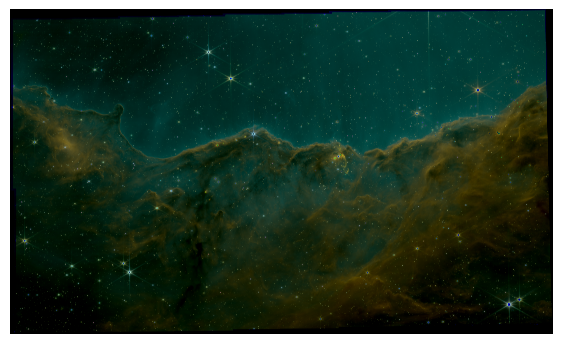

In [25]:
def load_fits_data(path):
    with fits.open(path) as hdul:
        return hdul['SCI'].data

F090W = load_fits_data("data/jw02731-o001_t017_nircam_clear-f090w_i2d.fits")
F187N = load_fits_data("data/jw02731-o001_t017_nircam_clear-f187n_i2d_reproj.fits")
F200W = load_fits_data("data/jw02731-o001_t017_nircam_clear-f200w_i2d_reproj.fits")
F470N = load_fits_data("data/jw02731-o001_t017_nircam_f444w-f470n_i2d_reproj.fits")
F335M = load_fits_data("data/jw02731-o001_t017_nircam_clear-f335m_i2d_reproj.fits")
F444W = load_fits_data("data/jw02731-o001_t017_nircam_clear-f444w_i2d_reproj.fits")

data_all = np.zeros((F090W.shape[0],F090W.shape[1],3))

data_all[:,:,0] = F444W + F470N + F335M
data_all[:,:,1] = F200W + F187N + F470N + (0.5 * F335M)
data_all[:,:,2] = F090W + F187N


data_all_res = rescale_image(data_all)

def remap(data):
    data_tmp = data.copy()

    dmin = data_tmp.min()
    dmax = data_tmp.max()
    return (data_tmp - dmin)/(dmax-dmin)

rgb_image = np.zeros((F090W.shape[0],F090W.shape[1],3))

rgb_image = remap(data_all_res)

f,ax = plt.subplots(1,1,figsize=(7,7))
ax.axis('off')
ax.imshow(rgb_image, origin='lower')

plt.savefig('ngc3324_false_3color.png',bbox_inches='tight',pad_inches=0,dpi=600)